# Exploratory Data Analysis
## CVD Fairness Dissertation — NB0b

**Purpose:** Explore feature distributions, sex-stratified patterns, and feature correlations in the cleaned dataset. Findings here informed preprocessing decisions and the clinical benchmarking in later notebooks.

**Input:** `data/processed/cardio_baseline_clean.csv`  
**Outputs:** `outputs/eda/`


## 1. Imports and Paths

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_PATH  = Path("../processed/cardio_baseline_clean.csv")
OUTPUT_DIR = Path("../../outputs/eda")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape : {df.shape}")
print(f"Columns       : {list(df.columns)}")

Dataset shape : (68177, 12)
Columns       : ['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'age_years']


In [9]:
assert df.isnull().sum().sum() == 0, "Nulls found in EDA dataset"
assert "gender" in df.columns, "gender column missing"
assert "cardio" in df.columns, "cardio column missing"
assert set(df["gender"].unique()) == {0, 1}, "Unexpected gender values"
assert 67000 < len(df) < 69000, f"Unexpected dataset size: {len(df)}"

print(f"Sanity checks passed ({len(df):,} rows)")

Sanity checks passed (68,177 rows)


## 2. Feature Distributions by Sex

Histograms for all continuous features, split by sex, to check for distributional differences that may affect model behaviour.

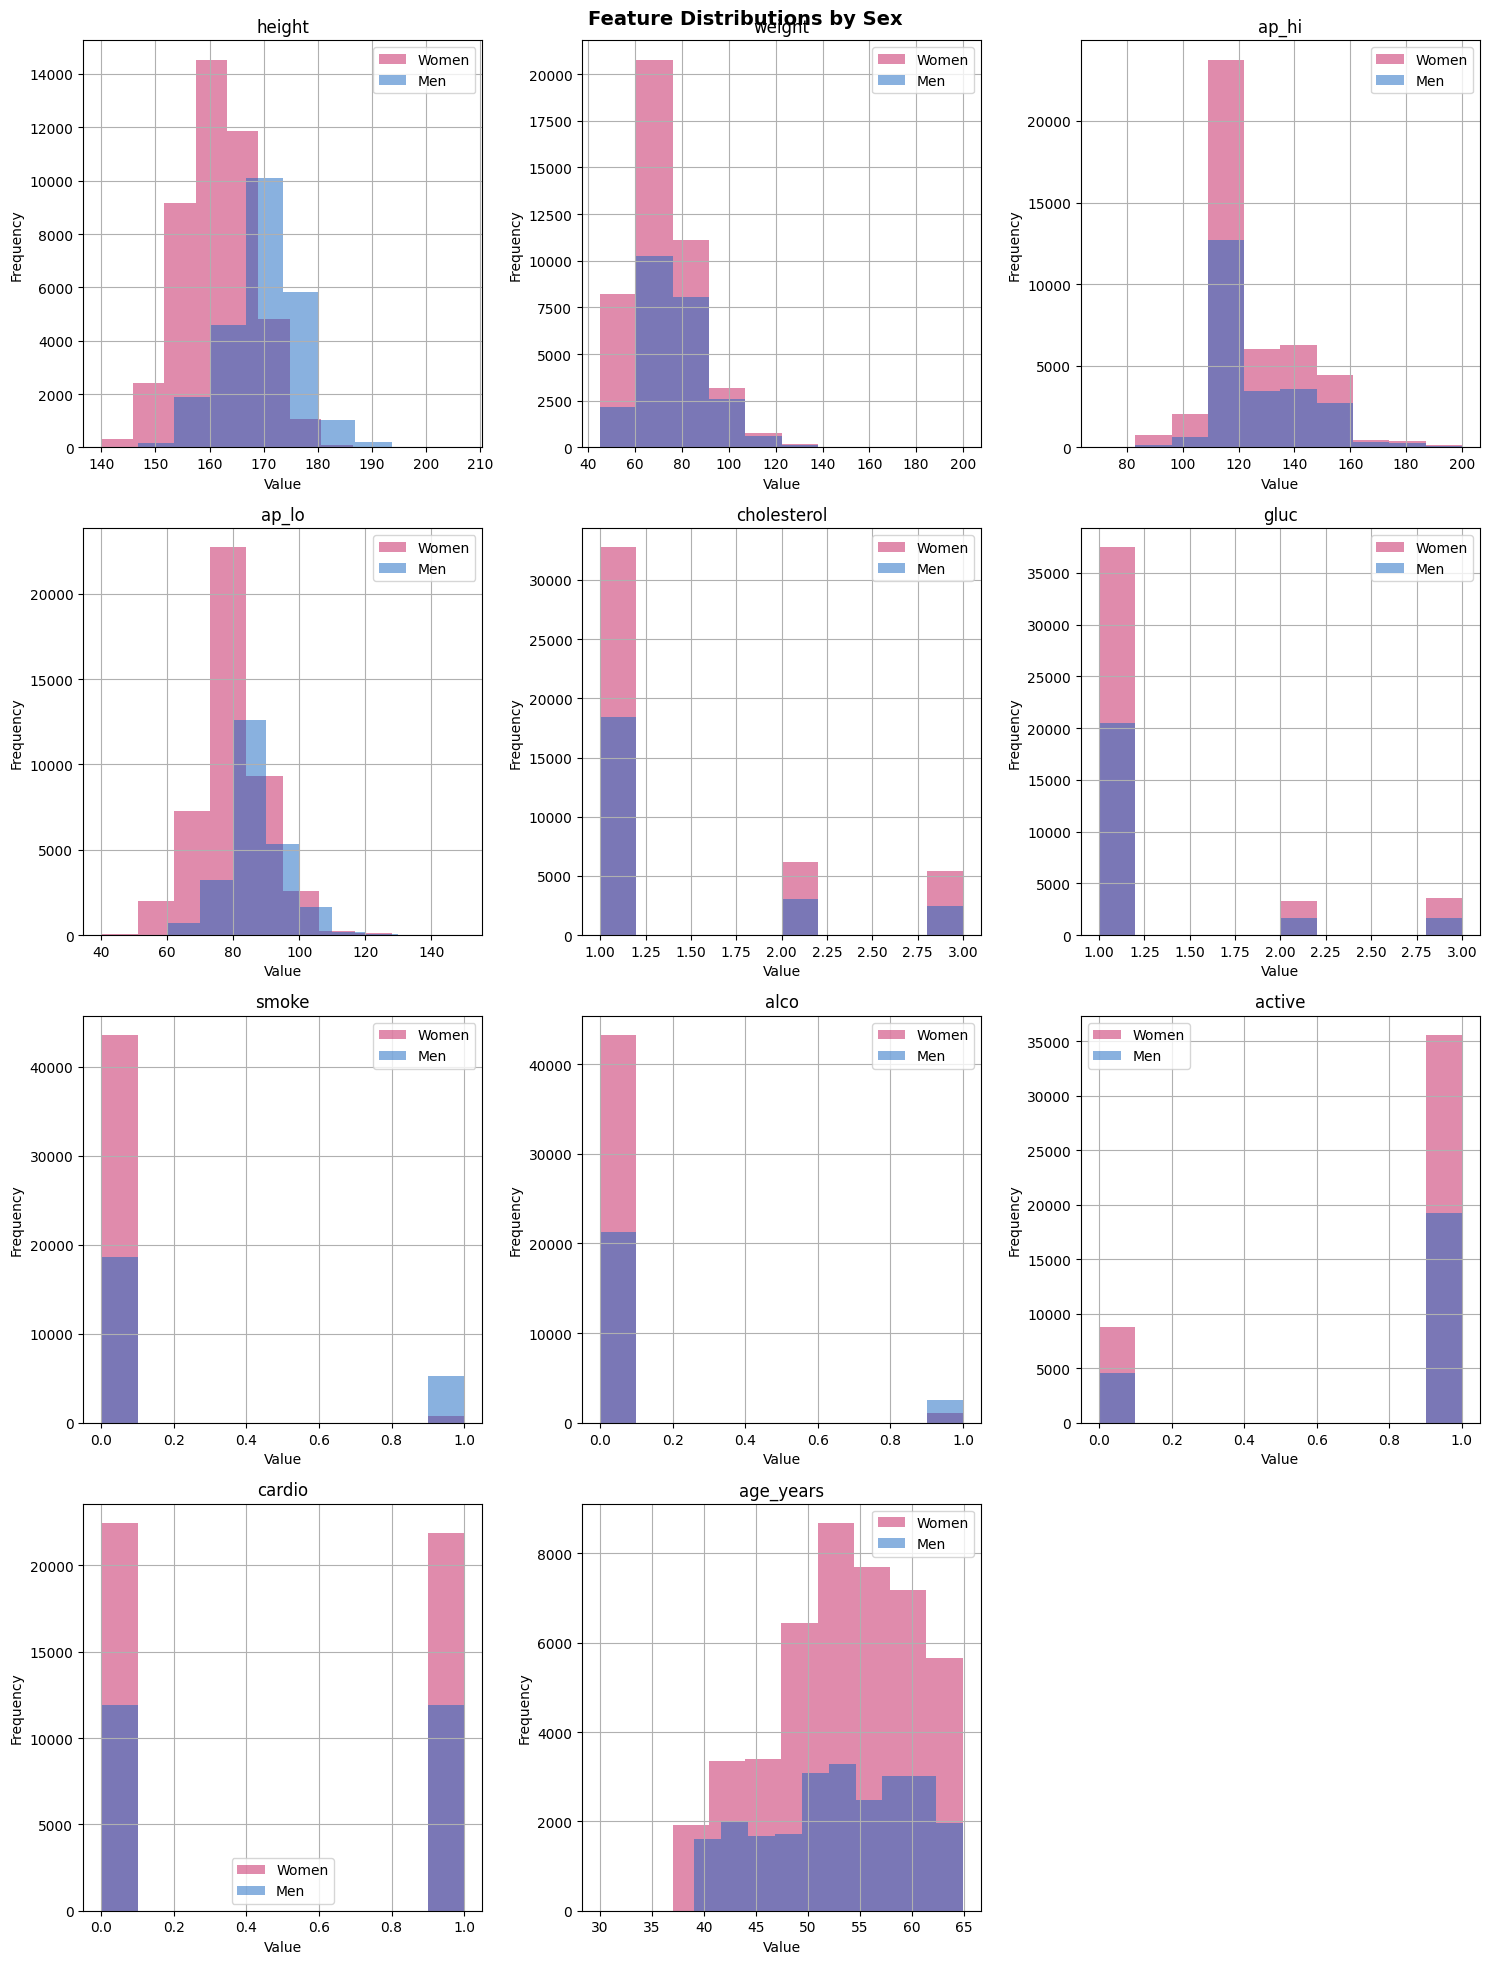

Saved → distributions_by_sex.png


In [7]:
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns
numeric_cols = [c for c in numeric_cols if c not in ["gender"]]

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 20))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    df[df["gender"] == 0][col].hist(ax=axes[idx], alpha=0.5, label="Women", color="#c2185b")
    df[df["gender"] == 1][col].hist(ax=axes[idx], alpha=0.5, label="Men",   color="#1565c0")
    axes[idx].set_title(col)
    axes[idx].set_xlabel("Value")
    axes[idx].set_ylabel("Frequency")
    axes[idx].legend()

for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Feature Distributions by Sex", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "distributions_by_sex.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → distributions_by_sex.png")

## 3. Sex-Stratified Categorical Feature Rates

Crosstabs for cholesterol, glucose, and lifestyle features by sex. These highlight where the dataset shows sex-based differences in feature distributions.

In [10]:
print("Cholesterol distribution by sex:")
print(pd.crosstab(df["gender"], df["cholesterol"], normalize="index").round(3))

print("\nGlucose distribution by sex:")
print(pd.crosstab(df["gender"], df["gluc"], normalize="index").round(3))

print("\nLifestyle features by sex (mean rates):")
print(df.groupby("gender")[["smoke", "alco", "active"]].mean().round(3))

Cholesterol distribution by sex:
cholesterol      1      2      3
gender                          
0            0.738  0.140  0.122
1            0.771  0.127  0.102

Glucose distribution by sex:
gluc        1      2      3
gender                     
0       0.845  0.075  0.080
1       0.860  0.072  0.069

Lifestyle features by sex (mean rates):
        smoke   alco  active
gender                      
0       0.018  0.025   0.802
1       0.219  0.106   0.806


**Observations:**
- **Cholesterol / Glucose:** Proportions broadly similar across sex, with minor differences.
- **Smoking:** 1.8% of women vs 21.9% of men — a large difference. As smoking and alcohol are self-reported, women may underreport due to social norms, meaning this gap may partially reflect reporting bias rather than true prevalence.
- **Alcohol:** 2.5% women vs 10.6% men.
- **Physical activity:** Similar across sex.

## 4. CVD Rate by Sex

CVD rate by sex:
gender
Female    0.493
Male      0.499
Name: cardio, dtype: float64


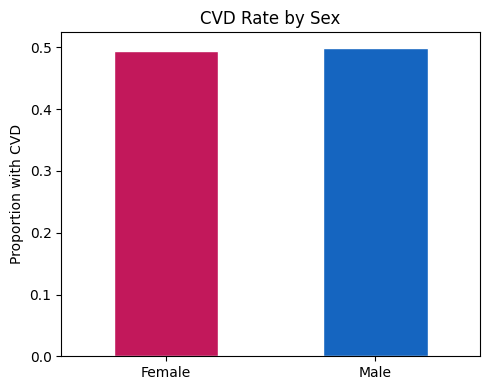

In [11]:
cvd_by_sex = df.groupby("gender")["cardio"].mean().rename({0: "Female", 1: "Male"})
print("CVD rate by sex:")
print(cvd_by_sex.round(3))

fig, ax = plt.subplots(figsize=(5, 4))
cvd_by_sex.plot(kind="bar", ax=ax, color=["#c2185b", "#1565c0"], edgecolor="white")
ax.set_title("CVD Rate by Sex")
ax.set_ylabel("Proportion with CVD")
ax.set_xlabel("")
ax.set_xticklabels(["Female", "Male"], rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cvd_rate_by_sex.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Feature Correlation Matrix

Computed on training features only (gender excluded as it is a categorical protected attribute). Pairs with correlation above 0.4 informed the feature engineering interventions in the bias mitigation stage.

Correlation matrix:
             height  weight  ap_hi  ap_lo  cholesterol   gluc  smoke   alco  active  age_years
height        1.000   0.303  0.012  0.031       -0.058 -0.022  0.197  0.099  -0.010     -0.089
weight        0.303   1.000  0.267  0.250        0.141  0.107  0.066  0.067  -0.017      0.054
ap_hi         0.012   0.267  1.000  0.731        0.195  0.094  0.027  0.035  -0.001      0.210
ap_lo         0.031   0.250  0.731  1.000        0.161  0.074  0.024  0.037  -0.001      0.155
cholesterol  -0.058   0.141  0.195  0.161        1.000  0.450  0.010  0.035   0.008      0.155
gluc         -0.022   0.107  0.094  0.074        0.450  1.000 -0.006  0.010  -0.008      0.099
smoke         0.197   0.066  0.027  0.024        0.010 -0.006  1.000  0.341   0.025     -0.048
alco          0.099   0.067  0.035  0.037        0.035  0.010  0.341  1.000   0.025     -0.029
active       -0.010  -0.017 -0.001 -0.001        0.008 -0.008  0.025  0.025   1.000     -0.010
age_years    -0.089   0.054  0

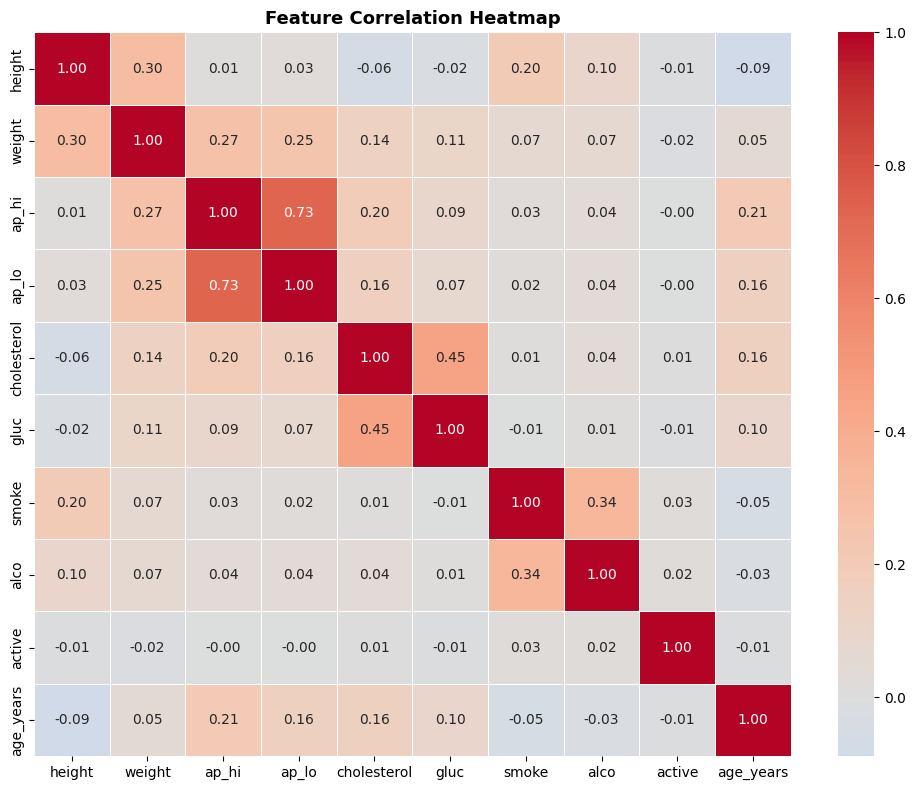

Saved → correlation_heatmap.png


In [12]:
X = df.drop(columns=["cardio", "gender"])
corr_matrix = X.corr(numeric_only=True)

print("Correlation matrix:")
print(corr_matrix.round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, linewidths=0.5)
ax.set_title("Feature Correlation Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → correlation_heatmap.png")

In [15]:
# Highlight pairs with correlation above threshold
THRESHOLD = 0.3
high_corr = (corr_matrix.abs() > THRESHOLD) & (corr_matrix != 1.0)
pairs = [(i, j, corr_matrix.loc[i, j])
         for i in corr_matrix.columns
         for j in corr_matrix.columns
         if i < j and high_corr.loc[i, j]]

print(f"Feature pairs with |correlation| > {THRESHOLD}:")
for i, j, val in sorted(pairs, key=lambda x: abs(x[2]), reverse=True):
    print(f"  {i:<15} — {j:<15} : {val:+.3f}")

Feature pairs with |correlation| > 0.3:
  ap_hi           — ap_lo           : +0.731
  cholesterol     — gluc            : +0.450
  alco            — smoke           : +0.341
  height          — weight          : +0.303


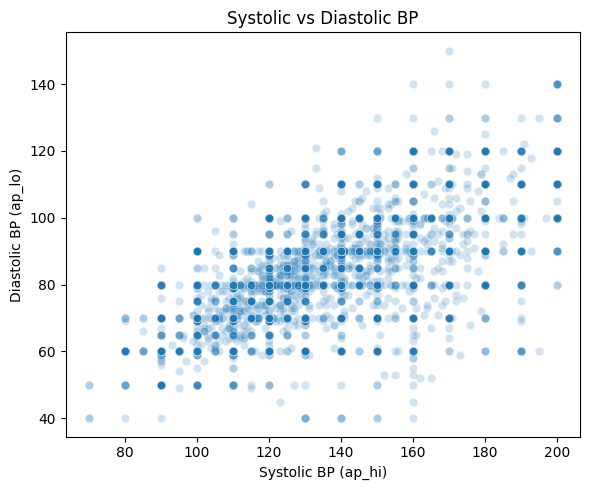

In [16]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(data=df, x="ap_hi", y="ap_lo", alpha=0.2, ax=ax)
ax.set_title("Systolic vs Diastolic BP")
ax.set_xlabel("Systolic BP (ap_hi)")
ax.set_ylabel("Diastolic BP (ap_lo)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "scatter_ap_hi_ap_lo.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Systolic BP Distribution by Sex

The KDE plot below shows how systolic BP is distributed across male and female patients, with reference lines from Ji et al. showing that CVD risk begins increasing at a lower threshold in women (110 mmHg) than men (130 mmHg). This motivates the clinical benchmarking in the SHAP analysis.

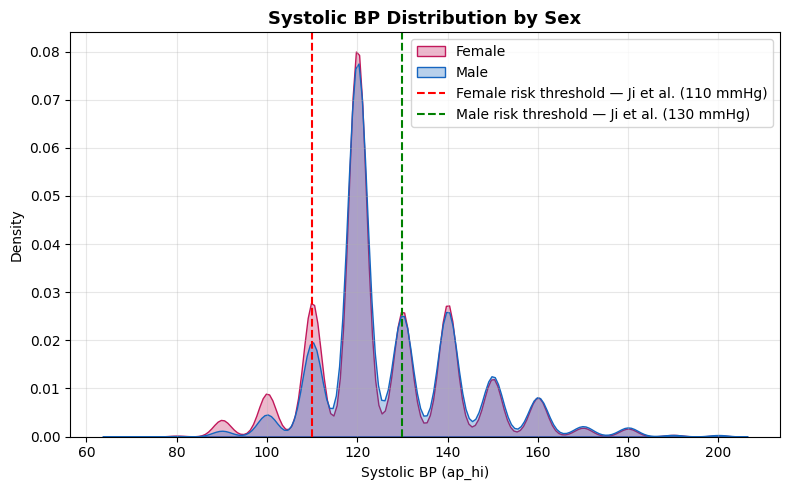

Saved → kde_ap_hi_by_sex.png


In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.kdeplot(data=df[df["gender"] == 0], x="ap_hi",
            label="Female", fill=True, alpha=0.3, color="#c2185b")
sns.kdeplot(data=df[df["gender"] == 1], x="ap_hi",
            label="Male",   fill=True, alpha=0.3, color="#1565c0")
ax.axvline(x=110, color="red",   linestyle="--", linewidth=1.5,
           label="Female risk threshold — Ji et al. (110 mmHg)")
ax.axvline(x=130, color="green", linestyle="--", linewidth=1.5,
           label="Male risk threshold — Ji et al. (130 mmHg)")
ax.set_title("Systolic BP Distribution by Sex", fontsize=13, fontweight="bold")
ax.set_xlabel("Systolic BP (ap_hi)")
ax.set_ylabel("Density")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "kde_ap_hi_by_sex.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → kde_ap_hi_by_sex.png")

## 7. Feature Correlation with CVD Outcome

Feature correlation with cardio outcome:
ap_hi          0.430
ap_lo          0.340
age_years      0.239
cholesterol    0.221
weight         0.178
gluc           0.089
active        -0.038
smoke         -0.017
height        -0.016
alco          -0.009
gender         0.006


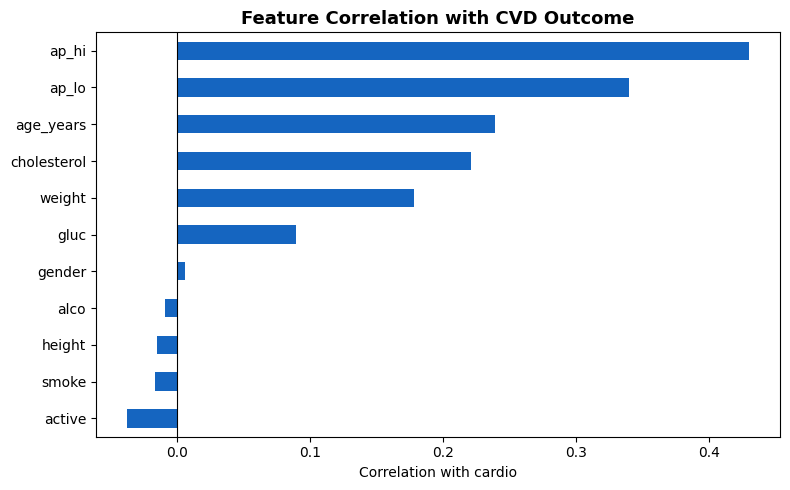

Saved → feature_target_correlation.png


In [18]:
feature_target_corr = df.corr(numeric_only=True)["cardio"].drop("cardio")
feature_target_corr = feature_target_corr.sort_values(key=np.abs, ascending=False)

print("Feature correlation with cardio outcome:")
print(feature_target_corr.round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 5))
feature_target_corr.sort_values().plot(kind="barh", ax=ax, color="#1565c0")
ax.set_title("Feature Correlation with CVD Outcome", fontsize=13, fontweight="bold")
ax.set_xlabel("Correlation with cardio")
ax.axvline(x=0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "feature_target_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → feature_target_correlation.png")

## 8. Smoking, Sex, and CVD

Smoking is self-reported and shows a large sex gap in this dataset (1.8% women vs 21.9% men). This table checks whether that gap interacts with CVD diagnosis rates, relevant to the label bias discussion.

In [ ]:
smokers = df[df["smoke"] == 1]
print("CVD counts among smokers by sex:")
print(pd.crosstab(smokers["gender"], smokers["cardio"]).rename(
    index={0: "Female", 1: "Male"},
    columns={0: "No CVD", 1: "CVD"}
))

print("\nCVD counts by sex and smoking status:")
print(pd.crosstab(
    [df["gender"], df["smoke"]],
    df["cardio"]
).rename(
    index={(0, 0): "Female Non-smoker", (0, 1): "Female Smoker",
           (1, 0): "Male Non-smoker",   (1, 1): "Male Smoker"},
    columns={0: "No CVD", 1: "CVD"}
))